# Hacker News — Exploratory Data Analysis

**Author:** Ines Amdjahed  
**Date:** 2025  
**Dataset:** [Hacker News on Kaggle](https://www.kaggle.com/datasets/hacker-news/hacker-news)

> 📁 **Setup:** Download `hacker_news.csv` from the Kaggle link above and place it in the same folder as this notebook.

## Introduction

This dataset contains stories and comments from Hacker News (2015–2016). Each story includes a unique ID, the author, the timestamp, and the number of points received.

Hacker News is a social news website focusing on computer science and entrepreneurship, run by Y Combinator. Content is broadly defined as *anything that gratifies one's intellectual curiosity*.

You can find the dataset on [Kaggle](https://www.kaggle.com/datasets/hacker-news/hacker-news).

## Objectives

In this EDA, we investigate the factors that drive engagement on Hacker News posts:

- What elements contribute to a post's popularity, as measured by points and number of comments?
- Are there certain authors (influencers) who consistently receive more engagement?
- Do specific topics or keywords in titles attract higher engagement?
- How has post volume evolved over time?

**Hypotheses:**
- Posts with higher points tend to generate more comments.
- Some authors consistently produce viral content.
- Certain keywords in titles are associated with higher engagement.
- Post volume has grown over time, reflecting community growth.

## 1. Setup & Global Exploration

Before diving into specific questions, we get an overall understanding of the dataset's structure, size, data types, and key variables.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter  # ✅ Built-in Python — no install needed

# ── Visual theme (applied once, affects all plots) ──────────────────────────
sns.set_theme(style="darkgrid")
plt.rcParams["figure.facecolor"]  = "#0d1117"
plt.rcParams["axes.facecolor"]    = "#161b22"
plt.rcParams["text.color"]        = "white"
plt.rcParams["axes.labelcolor"]   = "white"
plt.rcParams["xtick.color"]       = "white"
plt.rcParams["ytick.color"]       = "white"
plt.rcParams["axes.titlecolor"]   = "white"
plt.rcParams["grid.color"]        = "#30363d"

# Consistent color palette
PALETTE = ["#00f5ff", "#0080ff", "#00ff88", "#ff8c00"]

In [2]:
# ✅ Relative path — works on any machine as long as the CSV is in the same folder
df = pd.read_csv("hacker_news.csv")

In [3]:
df.head()

,id,title,url,num_points,num_comments,author,created_at
0,12224879,Interactive Dynamic Video,http://www.interactivedynamicvideo.com/,386,52,ne0phyte,8/4/2016 11:52
1,11964716,Florida DJs May Face Felony for April Fools' W...,http://www.thewire.com/entertainment/2013/04/f...,2,1,vezycash,6/23/2016 22:20
2,11919867,Technology ventures: From Idea to Enterprise,https://www.amazon.com/Technology-Ventures-Ent...,3,1,hswarna,6/17/2016 0:01
3,10301696,Note by Note: The Making of Steinway L1037 (2007),http://www.nytimes.com/2007/11/07/movies/07ste...,8,2,walterbell,9/30/2015 4:12
4,10482257,Title II kills investment? Comcast and other I...,http://arstechnica.com/business/2015/10/comcas...,53,22,Deinos,10/31/2015 9:48


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20099 entries, 0 to 20098
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            20099 non-null  int64 
 1   title         20099 non-null  object
 2   url           17659 non-null  object
 3   num_points    20099 non-null  int64 
 4   num_comments  20099 non-null  int64 
 5   author        20099 non-null  object
 6   created_at    20099 non-null  object
dtypes: int64(3), object(4)
memory usage: 1.1+ MB


The dataset contains **20,099 rows** and **7 columns**, including 3 numerical variables and 4 categorical (object) variables.

Each story includes a unique story ID, the author, the timestamp, and the number of points received.

## 2. Distribution of Key Variables

We examine the distributions of **points** and **number of comments** to identify typical values, outliers, and the overall shape of the data.

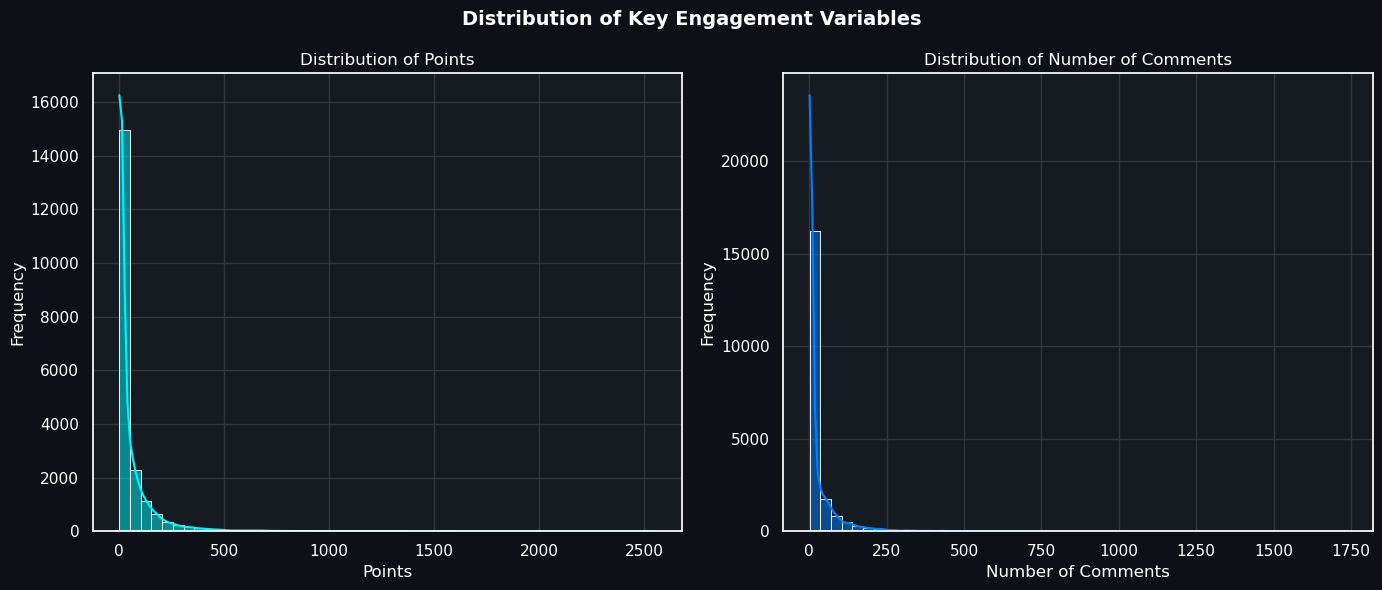

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Distribution of Key Engagement Variables", fontsize=14, fontweight="bold")

sns.histplot(df['num_points'], bins=50, kde=True, ax=axes[0], color=PALETTE[0])
axes[0].set_title('Distribution of Points')
axes[0].set_xlabel('Points')
axes[0].set_ylabel('Frequency')

sns.histplot(df['num_comments'], bins=50, kde=True, ax=axes[1], color=PALETTE[1])
axes[1].set_title('Distribution of Number of Comments')
axes[1].set_xlabel('Number of Comments')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Both distributions are heavily right-skewed. Let's explore the extremes of `num_points`.

In [6]:
min_points = df["num_points"].min()
count_min = df[df["num_points"] == min_points]
print(f"Minimum number of points: {min_points}")
print(f"Number of posts with minimum points: {len(count_min)}")
count_min.head()

Minimum number of points: 1
Number of posts with minimum points: 2098


,id,title,url,num_points,num_comments,author,created_at
15,11403750,Review my AI based marketing bot,http://beta.crowdfireapp.com/?beta=agnipath,1,2,abhishekmaddy,4/1/2016 9:45
18,12121216,Valid.ly Never send another OOPS message,https://www.valid.ly,1,1,validly,7/19/2016 12:05
19,11079821,APOD: LIGO detects gravity waves...,http://apod.nasa.gov/apod/astropix.html,1,2,AliCollins,2/11/2016 12:57
21,11610310,Ask HN: Aby recent changes to CSS that broke m...,NaN,1,1,polskibus,5/2/2016 10:14
26,11181546,US Robotics Network Taps,http://www.usr.com/en/products/networking-taps/,1,2,mkj,2/26/2016 14:35


There are **2,098 posts** that received only 1 point.

In [7]:
percentage_min = (len(count_min) / len(df)) * 100
print(f"{round(percentage_min, 2)}% of posts received only 1 point.")

10.44% of posts received only 1 point.


In [8]:
max_point = df["num_points"].max()
max_count = df[df["num_points"] == max_point]
print(f"Maximum number of points: {max_point}")
max_count

Maximum number of points: 2553


,id,title,url,num_points,num_comments,author,created_at
13280,12494998,Pardon Snowden,https://www.pardonsnowden.org/,2553,781,erlend_sh,9/14/2016 8:31


In [9]:
df["num_points"].describe()

count    20099.000000
mean        50.296632
std        107.110322
min          1.000000
25%          3.000000
50%          9.000000
75%         54.000000
max       2553.000000
Name: num_points, dtype: float64

- The median is only **9 points**, while the mean is pulled up by viral outliers.
- The distribution is **highly right-skewed**: a few exceptional posts dominate.
- This is a classic **power law** pattern, typical of social platforms.

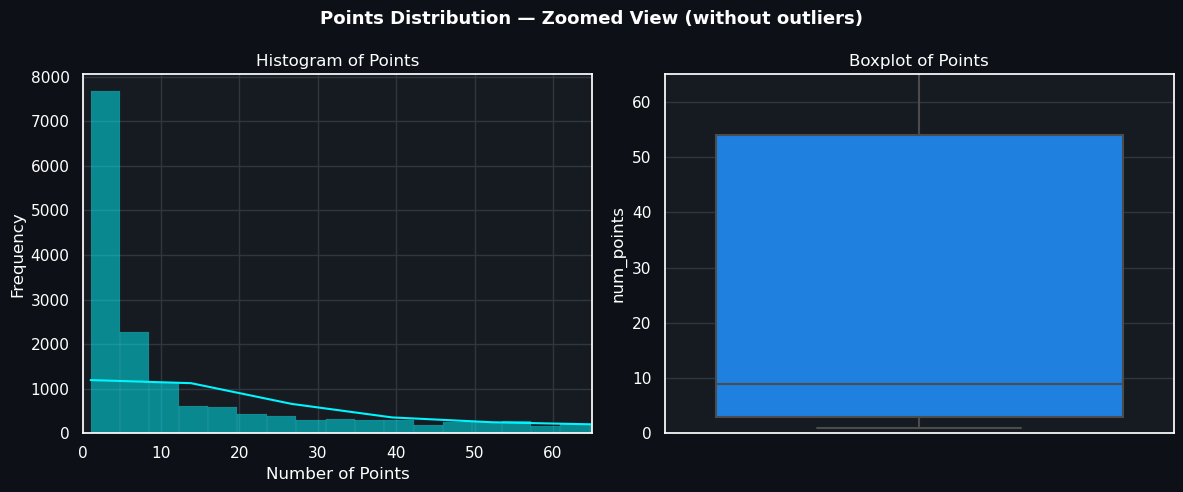

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Points Distribution — Zoomed View (without outliers)", fontsize=13, fontweight="bold")

sns.histplot(df["num_points"], kde=True, ax=axes[0], color=PALETTE[0])
axes[0].set_xlim(0, 65)
axes[0].set_title("Histogram of Points")
axes[0].set_xlabel("Number of Points")
axes[0].set_ylabel("Frequency")

sns.boxplot(y=df["num_points"], ax=axes[1], color=PALETTE[1])
axes[1].set_ylim(0, 65)
axes[1].set_title("Boxplot of Points")

plt.tight_layout()
plt.show()

### Interpretation

The data reveals a highly skewed distribution of points, where most posts receive relatively low engagement. This pattern is typical in social news platforms — a few standout posts capture significant attention while the vast majority receive modest scores.

Such insights are crucial for understanding user interaction dynamics and the nature of content popularity on Hacker News.

In [11]:
df['num_comments'].describe()

count    20099.000000
mean        24.803025
std         56.108639
min          1.000000
25%          1.000000
50%          3.000000
75%         21.000000
max       1733.000000
Name: num_comments, dtype: float64

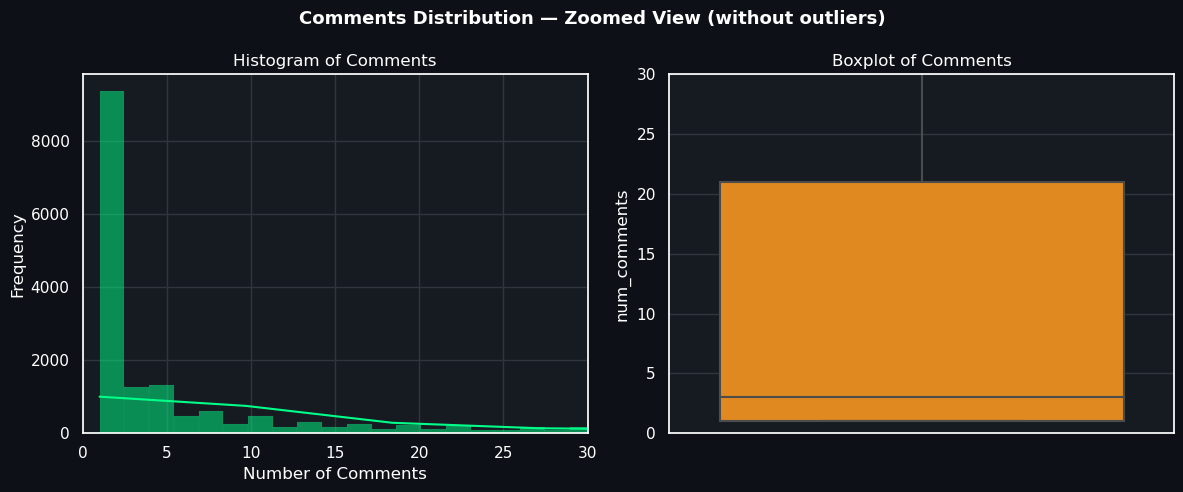

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Comments Distribution — Zoomed View (without outliers)", fontsize=13, fontweight="bold")

sns.histplot(df["num_comments"], kde=True, ax=axes[0], color=PALETTE[2])
axes[0].set_xlim(0, 30)
axes[0].set_title("Histogram of Comments")
axes[0].set_xlabel("Number of Comments")
axes[0].set_ylabel("Frequency")

sns.boxplot(y=df["num_comments"], ax=axes[1], color=PALETTE[3])
axes[1].set_ylim(0, 30)
axes[1].set_title("Boxplot of Comments")

plt.tight_layout()
plt.show()

### Interpretation

The distribution of comments mirrors the points distribution but with an even stronger concentration at low values. Most posts receive very few comments, while a small number generate extensive discussion — highlighting different dynamics between voting and commenting behaviors.

## 3. Identifying Viral Posts

We define viral posts using the **95th percentile** as threshold for both points and comments.

In [13]:
points_threshold   = df['num_points'].quantile(0.95)
comments_threshold = df['num_comments'].quantile(0.95)

print(f"Points threshold for viral posts (95th percentile):   {points_threshold}")
print(f"Comments threshold for viral posts (95th percentile): {comments_threshold}")

viral_posts = df[
    (df['num_points']   >= points_threshold) |
    (df['num_comments'] >= comments_threshold)
]
print(f"\nNumber of viral posts: {len(viral_posts)} ({round(len(viral_posts)/len(df)*100, 1)}% of total)")

Points threshold for viral posts (95th percentile):   221.0
Comments threshold for viral posts (95th percentile): 125.0

Number of viral posts: 1382 (6.9% of total)


### Interpretation

Using the 95th percentile, a post is considered viral if it receives at least **221 points** or **125 comments**. Only **1,382 posts** (~6.9%) meet this threshold — a small but highly influential subset.

## 4. Correlation Between Points and Comments

Correlation matrix between points and comments:
              num_points  num_comments
num_points      1.000000      0.783348
num_comments    0.783348      1.000000


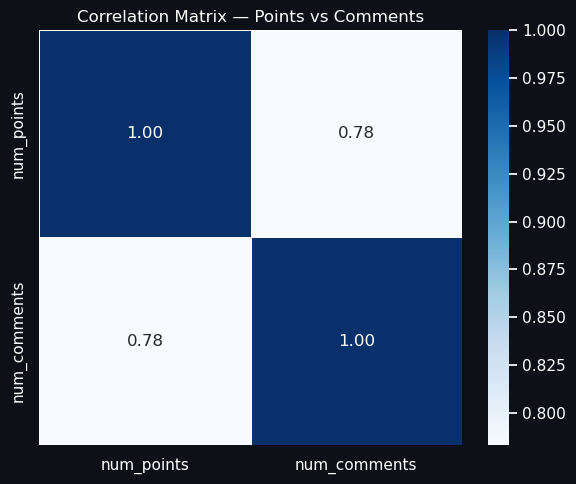

In [14]:
corr = df[['num_points', 'num_comments']].corr()
print("Correlation matrix between points and comments:")
print(corr)

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Correlation Matrix — Points vs Comments")
plt.tight_layout()
plt.show()

### Interpretation

The correlation coefficient between points and comments is approximately **0.78** — a strong positive relationship. Posts with more votes tend to attract more discussion. However, exceptions exist: some posts accumulate many points but few comments (passive approval), and vice versa (controversial content that sparks debate without broad support).

## 5. Top Authors with Viral Posts

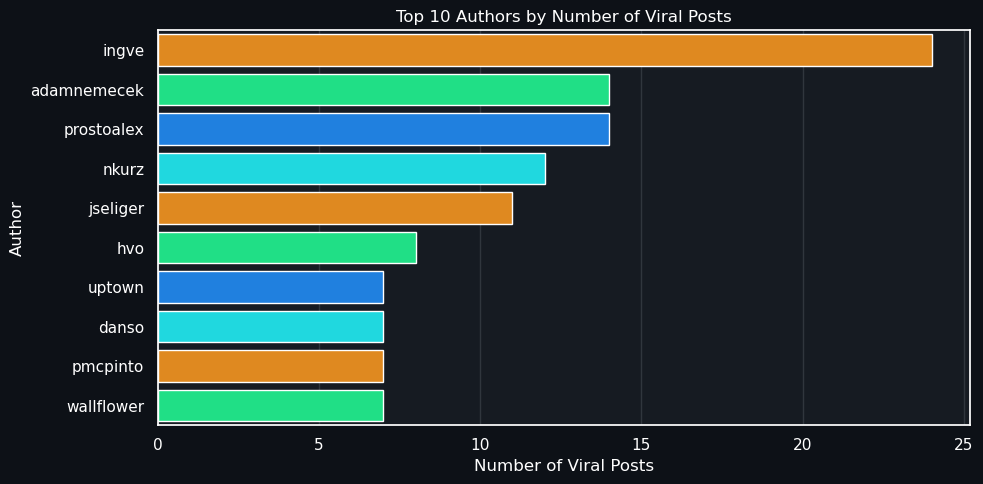

ingve          24
adamnemecek    14
prostoalex     14
nkurz          12
jseliger       11
hvo             8
uptown          7
danso           7
pmcpinto        7
wallflower      7
Name: author, dtype: int64


In [15]:
top_authors_viral = viral_posts['author'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_authors_viral.values, y=top_authors_viral.index, palette=PALETTE[::-1] * 3)
plt.title("Top 10 Authors by Number of Viral Posts")
plt.xlabel("Number of Viral Posts")
plt.ylabel("Author")
plt.tight_layout()
plt.show()

print(top_authors_viral)

### Interpretation

The top author *ingve* has **24 viral posts**, followed by *adamnemecek* and *prostoalex* with 14 each. A small group of authors consistently produces highly engaging content, confirming the influencer hypothesis.

## 6. Text Analysis — Keywords in Viral Post Titles

We extract the most frequent words from viral post titles to identify which topics drive engagement.

> 💡 **Note:** We use Python's built-in `Counter` class from the `collections` module — it replaces manual dictionary counting with a single, clean call.

In [16]:
regex_pattern = r'\b[a-zA-Z]{4,}\b'  # words of at least 4 characters

def extract_words(titles, pattern):
    words_list = []
    for title in titles:
        if isinstance(title, str):
            matches = re.findall(pattern, title.lower())
            words_list.extend(matches)
    return words_list

In [17]:
viral_titles = viral_posts['title'].dropna()
words_list   = extract_words(viral_titles, regex_pattern)

In [18]:
# ✅ Counter replaces the manual loop — same result, much cleaner
word_counts = Counter(words_list)

print("Top 20 words in viral post titles:")
for word, count in word_counts.most_common(20):
    print(f"  {word}: {count}")

Top 20 words in viral post titles:
  with: 69
  google: 50
  what: 43
  from: 42
  your: 34
  apple: 33
  that: 29
  open: 27
  about: 27
  show: 26
  facebook: 25
  after: 24
  than: 24
  code: 23
  more: 21
  microsoft: 21
  linux: 21
  first: 20
  years: 19
  learning: 19


In [19]:
stop_words = {
    'what', 'that', 'your', 'with', 'from', 'about', 'after', 'than', 'more', 'show',
    'this', 'have', 'will', 'they', 'some', 'just', 'like', 'when', 'were', 'them',
    'then', 'also', 'into', 'only', 'over', 'such', 'here', 'very', 'than', 'who',
    'which', 'their', 'been', 'because', 'these', 'does', 'had', 'how', 'its', 'our',
    'out', 'off', 'too', 'now', 'new', 'one', 'all', 'any', 'can', 'but', 'and', 'for',
    'are', 'you', 'was', 'not', 'his', 'her', 'she', 'him', 'had', 'did', 'has', 'the',
    'a', 'an', 'in', 'on', 'at', 'by', 'of', 'to', 'is', 'as', 'if', 'or'
}

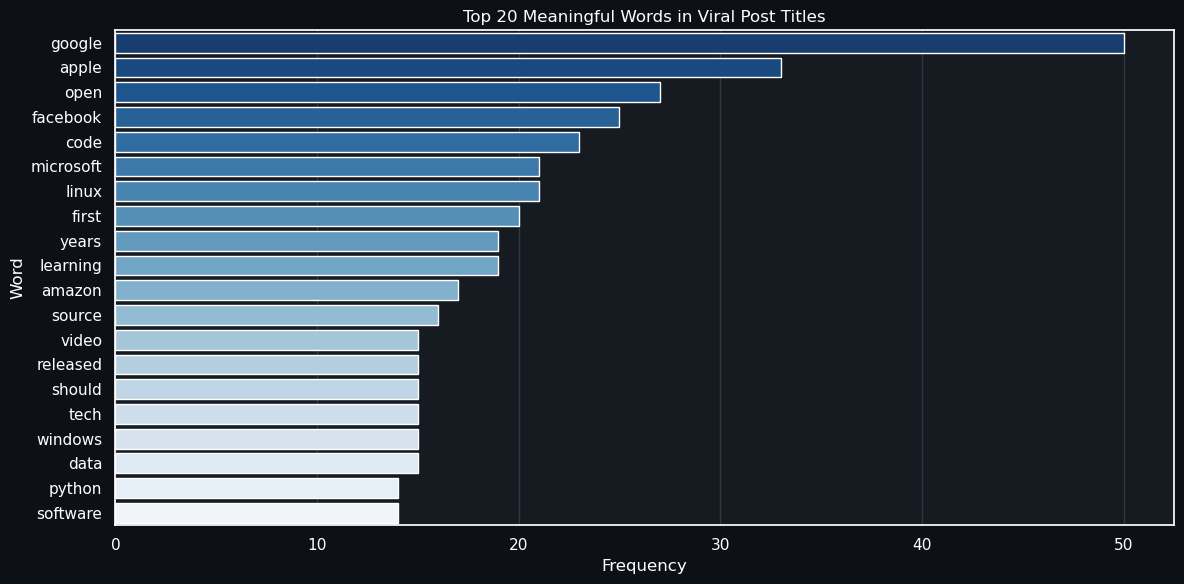

In [20]:
# ✅ Counter again — filter stop words directly in the comprehension
filtered_counts = Counter({w: c for w, c in word_counts.items() if w not in stop_words})

top_words = filtered_counts.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette="Blues_r")
plt.title("Top 20 Meaningful Words in Viral Post Titles")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

### Interpretation

After filtering stop words, the most frequent terms are major **tech brand names** (Google, Apple, Facebook, Microsoft) and **thematic keywords** (code, open, learning, source, video, released, data).

This confirms that viral content on Hacker News is strongly tied to big tech companies and topics like open source, software releases, and tech education.

In [21]:
proper_nouns = {'google', 'apple', 'facebook', 'microsoft', 'linux', 'amazon', 'python', 'windows'}

# ✅ Counter with exclusion of both stop words and proper nouns
thematic_counts = Counter({
    w: c for w, c in word_counts.items()
    if w not in stop_words and w not in proper_nouns
})

print("Top thematic words (excluding proper nouns):")
for word, count in thematic_counts.most_common(10):
    print(f"  {word}: {count}")

Top thematic words (excluding proper nouns):
  open: 27
  code: 23
  first: 20
  years: 19
  learning: 19
  source: 16
  video: 15
  released: 15
  should: 15
  tech: 15


### Interpretation

Excluding proper nouns, the dominant themes are *open*, *code*, *learning*, *source*, *video*, *released*, *tech* — reflecting the community's focus on **open source, education, and innovation**.

## 7. Temporal Analysis — Post Volume Over Time

In [22]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
print(f"Missing dates: {df['created_at'].isnull().sum()}")

Missing dates: 0


In [23]:
posts_per_year = df.groupby(df['created_at'].dt.year).size()
print(posts_per_year)

created_at
2015     6143
2016    13956
dtype: int64


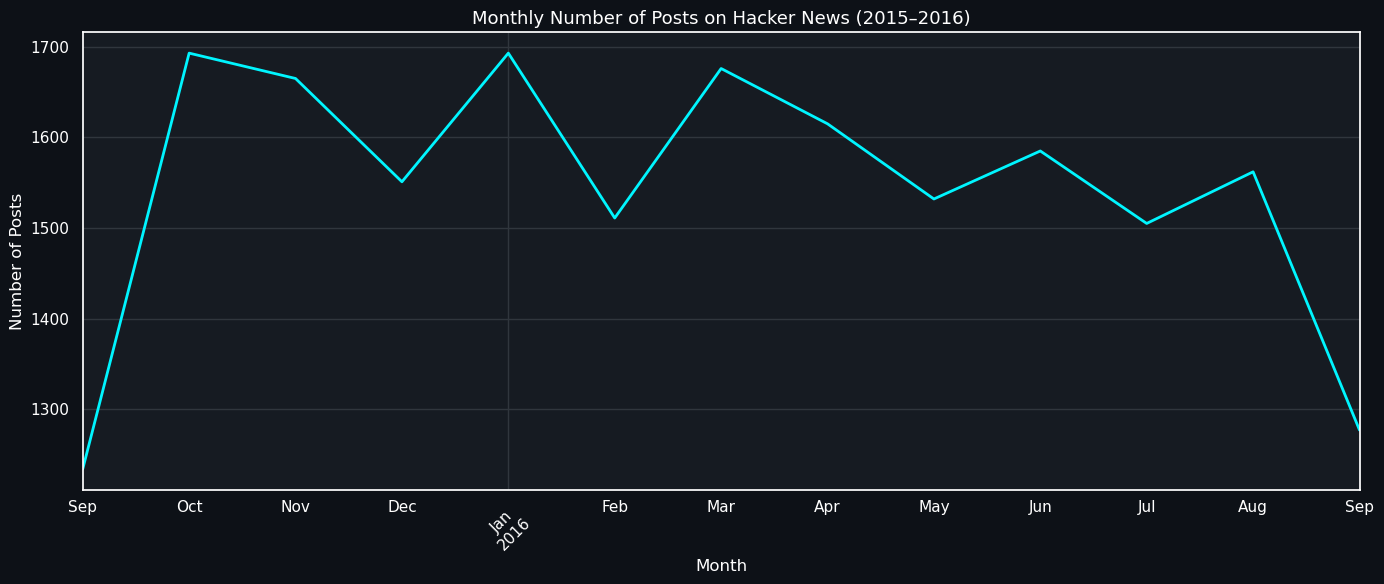

In [24]:
posts_per_month = df.groupby(df['created_at'].dt.to_period('M')).size()

plt.figure(figsize=(14, 6))
posts_per_month.plot(kind='line', color=PALETTE[0], linewidth=2)
plt.title('Monthly Number of Posts on Hacker News (2015–2016)', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
threshold_sensitive = posts_per_month.mean() + 0.5 * posts_per_month.std()
peaks_sensitive     = posts_per_month[posts_per_month > threshold_sensitive]

print(f"Number of peaks detected: {len(peaks_sensitive)}")
print(peaks_sensitive)

Number of peaks detected: 4
created_at
2015-10    1693
2015-11    1665
2016-01    1693
2016-03    1676
Freq: M, dtype: int64


In [26]:
for date_period, count in peaks_sensitive.items():
    start = date_period.to_timestamp()
    end   = start + pd.offsets.MonthEnd(1)

    posts_peak = df[(df['created_at'] >= start) & (df['created_at'] <= end)]

    print(f"\n📅 Peak month: {start.strftime('%Y-%m')} — {count} posts")
    print("   Top 5 titles:")
    for title in posts_peak['title'].value_counts().head(5).index:
        print(f"   · {title}")


📅 Peak month: 2015-10 — 1693 posts
   Top 5 titles:
   · Adobe confirms major Flash vulnerability
   · Show HN: Micro web framework for low-resource systems  live example on ESP8266
   · Yukon Moose Hunting
   · React Desktop  React UI Components for OS X El Capitan and Windows 10
   · Things to Avoid When Writing CSS

📅 Peak month: 2015-11 — 1665 posts
   Top 5 titles:
   · How to hijack a journal
   · Yahoo Hires McKinsey to Mull Reorg, as Mayer Demands Exec Pledge to Stay
   · How Apple Is Giving Design a Bad Name
   · For Better or for Worse
   · Hello, Im Mr. Null. My Name Makes Me Invisible to Computers

📅 Peak month: 2016-01 — 1693 posts
   Top 5 titles:
   · Whats Apples competitive edge going forward?
   · The New Republics Next Chapter
   · Adsvise  The ultimate social and digital ad size guide
   · R.I.P. Bitcoin. Its time to move on
   · OpenSSH and the dangers of unused code

📅 Peak month: 2016-03 — 1676 posts
   Top 5 titles:
   · Calculus Is So Last Century
   · 400Gbps

### Interpretation

Several peak months emerged between late 2015 and early 2016, with post volumes reaching 1,600–1,700 per month. These spikes correlate with major tech events:

- **October 2015** — Adobe Flash vulnerability, lightweight web frameworks
- **November 2015** — Corporate reorganizations, Apple design critiques
- **January 2016** — Bitcoin's future, OpenSSH security
- **March 2016** — DDoS attacks, Tesla firmware hacks, universal basic income debates

External events — especially security issues and major product news — are strong drivers of community activity.

## Conclusion

This EDA of the Hacker News dataset revealed several consistent patterns around engagement and virality:

- **Skewed distributions:** Both points and comments follow a power law — the vast majority of posts receive little engagement, while a small subset attracts disproportionate attention.
- **Strong correlation (r ≈ 0.78):** Points and comments are strongly linked, though exceptions suggest posts can generate passive approval (many points, few comments) or controversy (many comments, few points).
- **Influencers exist:** A small group of authors consistently produces viral content, confirming the influencer hypothesis.
- **Topic matters:** Viral titles systematically feature major tech brands and keywords around open source, learning, and software releases.
- **External events drive spikes:** Temporal peaks in post volume align with major security incidents, product launches, and tech news.

---

## Limitations & Next Steps

**Limitations:**
- The dataset covers a limited time window (2015–2016), which may not reflect current Hacker News dynamics.
- The text analysis relies on simple word frequency and does not capture context or sentiment.
- We have no data on post timing within a day, which could be a significant engagement factor.

**To go further, interesting next steps could include:**
- A **sentiment analysis** on post titles to explore whether positive or negative framing affects engagement.
- A **predictive model** to estimate a post's virality based on keywords and posting time.
- Expanding to a **more recent dataset** to see how topics have evolved since 2016.
- Analyzing **posting time patterns** (hour of day, day of week) and their impact on engagement.